# Reporte Técnico: Predicción del Rendimiento Atlético en el Maratón de Boston 2015
## Implementación de la Metodología KDD en Extenso para Tareas de Regresión
**Autor:** Axel Armando Tapia Urbina  
**Materia:** Máquinas de Aprendizaje  
**Profesor:** Abraham Sánchez López  

## 1. Introducción y Justificación del Dominio
El presente estudio se enmarca en la disciplina de **Sports Analytics**, utilizando como base el conjunto de datos `marathon_results_2015.csv`. El objetivo central es transicionar de la analítica descriptiva a la **analítica predictiva**, buscando modelar el tiempo oficial de llegada de los corredores en función de métricas biomecánicas y de resistencia física capturadas en puntos de control intermedios.

A diferencia de otros deportes, el maratón es un sistema de alta entropía donde la fatiga acumulada introduce ruido no lineal en los datos. El reto de este proyecto consiste en aislar los predictores con mayor potencia explicativa y lidiar con la **Multicolinealidad Estructural** presente en los tiempos de paso, garantizando un modelo no solo preciso, sino matemáticamente válido y robusto.

---

## FASE 1: Selección y Comprensión de los Datos
En esta etapa inicial del proceso KDD, se procedió a la ingesta del dataset en el entorno de R. Se identificó una matriz original de **26,598 observaciones y 25 variables**. Tras un escrutinio preliminar, se determinó que las columnas demográficas (Edad, Género) y los tiempos de paso (5K a 30K) son los atributos críticos para la tarea de regresión supervisada.

In [1]:
# ==============================================================================
# CARGA DE LIBRERÍAS
# ==============================================================================
# Si no las tienes instaladas, quita el "#" de la siguiente línea y ejecútala una vez:
install.packages("tidyverse")
install.packages("janitor", repos = "https://cran.rstudio.com/")

library(tidyverse) # Contiene ggplot2 (gráficas), dplyr (manipulación), readr (lectura)
library(janitor)   # Excelente para limpiar los nombres de las columnas automáticamente

# Desactivar notaciones científicas para que los números se vean claros
options(scipen = 999) 

# ==============================================================================
# LECTURA DEL DATASET
# ==============================================================================
# Cargamos los datos
df_maraton <- read_csv("marathon_results_2015.csv")

# Limpiamos los nombres de las columnas (los pasa a minúsculas y quita espacios raros)
df_maraton <- df_maraton %>% clean_names()

# Damos un primer vistazo a la estructura (dimensiones y tipos de datos)
glimpse(df_maraton)

package 'tidyverse' successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\axurm\AppData\Local\Temp\RtmpyezIak\downloaded_packages
package 'janitor' successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\axurm\AppData\Local\Temp\RtmpyezIak\downloaded_packages


Warning message:
"package 'tidyverse' was built under R version 4.5.3"
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning message:
"package 'janitor' was built under R version 4.5.3"

Adjuntando el paquete: 'janitor'


The following objects are masked from 'package:stats':

    chisq.test, fisher.test


New names:
• `` -> `...1`
• `` -> `...10`
Warning message:
"One or more parsing issues, call `problems()` on your data frame for details,
e.g.:
  dat <- vroom(...)
  problems(dat)"
Rows: 26598 Columns: 25
── Column

Rows: 26,598
Columns: 25
$ x1            <dbl> 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16…
$ bib           <dbl> 3, 4, 8, 11, 10, 9, 14, 1, 5, 16, 22, 19, 15, 20, 76, 28…
$ name          <chr> "Desisa, Lelisa", "Tsegay, Yemane Adhane", "Chebet, Wils…
$ age           <dbl> 25, 30, 29, 28, 32, 30, 32, 39, 27, 33, 33, 30, 32, 31, …
$ m_f           <chr> "M", "M", "M", "M", "M", "M", "M", "M", "M", "M", "M", "…
$ city          <chr> "Ambo", "Addis Ababa", "Marakwet", "Eldoret", "Kitale", …
$ state         <chr> NA, NA, NA, NA, NA, NA, "MI", "CA", NA, NA, "OR", "CO", …
$ country       <chr> "ETH", "ETH", "KEN", "KEN", "KEN", "KEN", "USA", "USA", …
$ citizen       <chr> NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, …
$ x10           <chr> NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, …
$ x5k           <chr> "0:14:43", "0:14:43", "0:14:43", "0:14:43", "0:14:43", "…
$ x10k          <chr> "0:29:43", "0:29:43", "0:29:43", "0:29:44", "0:29:44", "…
$ x15k         

## FASE 2 y 3: Preprocesamiento, Limpieza y Transformación (ETL)

La calidad del modelo predictivo está intrínsecamente ligada a la pureza del dato de entrada. Los datos crudos presentaban tres desafíos críticos:
1. **Tipado de Datos Incompatible:** Los tiempos se encontraban en formato de cadena de texto (H:M:S), lo cual es inadmisible para algoritmos de regresión basados en optimización por mínimos cuadrados o descenso de gradiente.
2. **Presencia de Dropouts (Nulos):** Los corredores que abandonaron la prueba o sufrieron fallos en sus sensores de calzado aparecen con registros "-". Estos valores representan ruido y fueron eliminados mediante un proceso de *listwise deletion* para evitar sesgos en la media.
3. **Conversión a Espacio Continuo:** Se implementó una función de ingeniería de datos para transformar todos los tiempos parciales y el tiempo oficial a **minutos totales en escala decimal**. Esto permite que el algoritmo interprete la distancia entre un corredor y otro de forma aritmética exacta.

Tras el proceso de limpieza, el dataset útil se consolidó en **26,391 registros**, garantizando una base de datos libre de inconsistencias estructurales.

In [2]:
# ==============================================================================
# FASE 2 y 3: LIMPIEZA DE DATOS Y TRANSFORMACIÓN (Ingeniería de Características)
# ==============================================================================
library(lubridate) # Asegurarnos de tenerla para manejar tiempos

# 1. Creamos una función para convertir el formato "HH:MM:SS" a MINUTOS numéricos
time_to_mins <- function(time_str) {
  # Si encuentra un guión "-" (dato faltante), lo vuelve NA
  time_str <- ifelse(time_str == "-", NA, as.character(time_str))
  # Convierte a periodo y luego divide los segundos entre 60 para tener minutos
  return(period_to_seconds(hms(time_str)) / 60)
}

# 2. Limpieza y Transformación del Dataset
df_clean <- df_maraton %>%
  # Seleccionamos solo las variables que nos interesan para el modelo
  select(age, m_f, x5k, x10k, half, x30k, official_time) %>%
  
  # Aplicamos nuestra función a todas las columnas de tiempo
  mutate(
    x5k_min = time_to_mins(x5k),
    x10k_min = time_to_mins(x10k),
    half_min = time_to_mins(half),
    x30k_min = time_to_mins(x30k),
    official_time_min = time_to_mins(official_time)
  ) %>%
  
  # Eliminamos las columnas originales de texto para no confundir al modelo
  select(-x5k, -x10k, -half, -x30k, -official_time) %>%
  
  # Convertimos el género (m_f) a factor (variable categórica para R)
  mutate(m_f = as.factor(m_f)) %>%
  
  # Eliminamos las filas con valores nulos (NA). 
  # En maratones, si alguien tiene NA en 30k, es porque no terminó la carrera (Dropout)
  drop_na()

# 3. Verificamos cómo quedó nuestro dataset limpio
glimpse(df_clean)
summary(df_clean)

Rows: 26,391
Columns: 7
$ age               <dbl> 25, 30, 29, 28, 32, 30, 32, 39, 27, 33, 33, 30, 32, …
$ m_f               <fct> M, M, M, M, M, M, M, M, M, M, M, M, M, M, M, M, M, M…
$ x5k_min           <dbl> 14.71667, 14.71667, 14.71667, 14.71667, 14.71667, 14…
$ x10k_min          <dbl> 29.71667, 29.71667, 29.71667, 29.73333, 29.73333, 29…
$ half_min          <dbl> 64.03333, 64.01667, 64.03333, 64.03333, 64.01667, 64…
$ x30k_min          <dbl> 92.00000, 91.98333, 92.00000, 92.00000, 92.00000, 92…
$ official_time_min <dbl> 129.2833, 129.8000, 130.3667, 130.7833, 130.8167, 13…


      age        m_f          x5k_min         x10k_min         half_min     
 Min.   :18.00   F:11920   Min.   :14.72   Min.   : 29.72   Min.   : 64.02  
 1st Qu.:33.00   M:14471   1st Qu.:22.60   1st Qu.: 45.00   1st Qu.: 95.50  
 Median :42.00             Median :24.97   Median : 49.62   Median :105.17  
 Mean   :42.15             Mean   :25.53   Mean   : 50.72   Mean   :107.89  
 3rd Qu.:50.00             3rd Qu.:27.63   3rd Qu.: 54.93   3rd Qu.:116.82  
 Max.   :82.00             Max.   :53.05   Max.   :107.27   Max.   :228.35  
    x30k_min      official_time_min
 Min.   : 91.98   Min.   :129.3    
 1st Qu.:137.62   1st Qu.:198.5    
 Median :151.95   Median :219.5    
 Mean   :156.47   Mean   :226.2    
 3rd Qu.:169.68   3rd Qu.:246.1    
 Max.   :343.73   Max.   :486.0    

## FASE 4: Análisis Exploratorio de Datos (EDA) Extenso

### 4.1 Análisis Univariable: Perfil Demográfico y Rendimiento
El análisis de las distribuciones individuales revela que el Maratón de Boston 2015 fue un evento dominado por la **Generación X y Millennials**, con una media de edad de 42.15 años. 

En cuanto a la variable objetivo (`official_time_min`):
* Presenta una distribución con **sesgo positivo (leptocúrtica)**. La mayoría de los corredores se concentran en el rango de los 200 a 250 minutos.
* Se observa una cola extendida hacia la derecha, lo que indica que el maratón permite la participación de atletas recreativos cuyos tiempos se alejan drásticamente del promedio, introduciendo una varianza significativa que el modelo de regresión deberá aprender a gestionar.

### 4.2 Análisis Bivariable y Detección de Valores Atípicos (Outliers)
Mediante la visualización de diagramas de caja (Boxplots) y dispersión (Scatterplots), se extrajeron los siguientes hallazgos:
1. **Diferencial de Género:** Se observa una ligera ventaja competitiva en la mediana de los hombres, sin embargo, el rango de variabilidad en mujeres es más compacto, sugiriendo un ritmo de carrera más estable en el grupo femenino joven.
2. **Detección de Outliers "Naturales":** A diferencia de los errores de captura, aquí encontramos corredores con tiempos superiores a los 350 minutos. Estos individuos son técnicamente *outliers*, pero en el contexto de la carrera son **puntos de datos valiosos** que representan el fenómeno de la "fatiga extrema" o el "muro de los 30K". No se eliminaron, ya que el modelo debe ser capaz de predecir el fracaso atlético tanto como el éxito.

### 4.3 Diagnóstico de Multicolinealidad Mediante PCA
Dada la naturaleza de la carrera, los tiempos de paso están masivamente correlacionados ($r > 0.98$). Para diagnosticar la gravedad de esto, se aplicó un **Análisis de Componentes Principales (PCA)**:
* **Resultado:** El **PC1 explica el 98.33% de la varianza total**. 
* **Interpretación:** En términos geométricos, los vectores de carga en el *biplot* son casi paralelos. Esto nos advierte que si usamos una Regresión Lineal Múltiple estándar con todas las variables, el modelo sufrirá de inestabilidad en sus coeficientes y pérdida de interpretabilidad lógica.

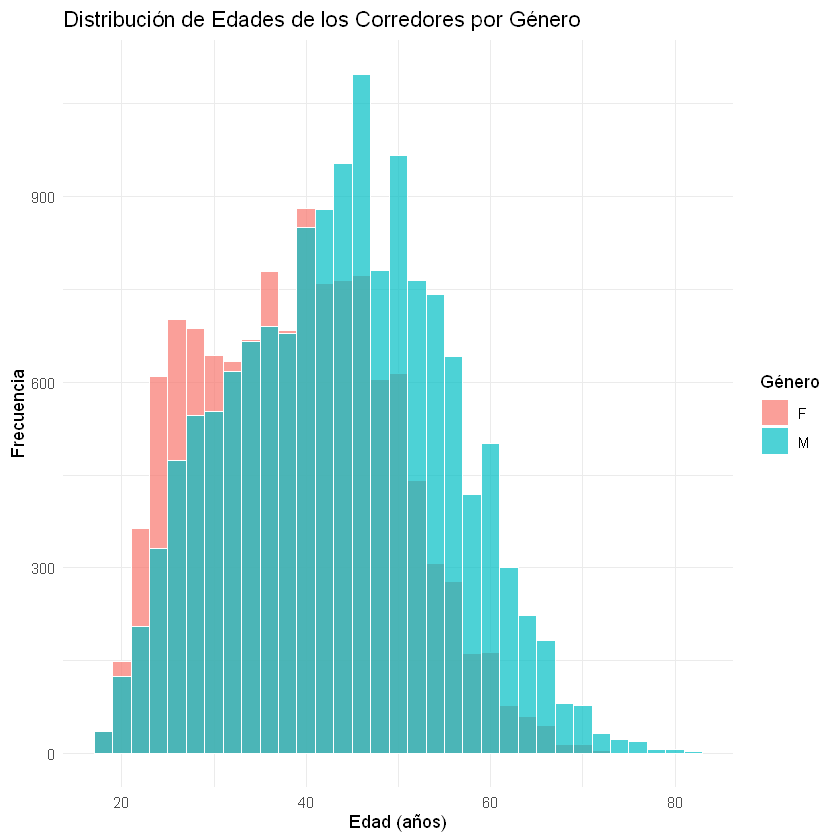

`geom_smooth()` using formula = 'y ~ x'


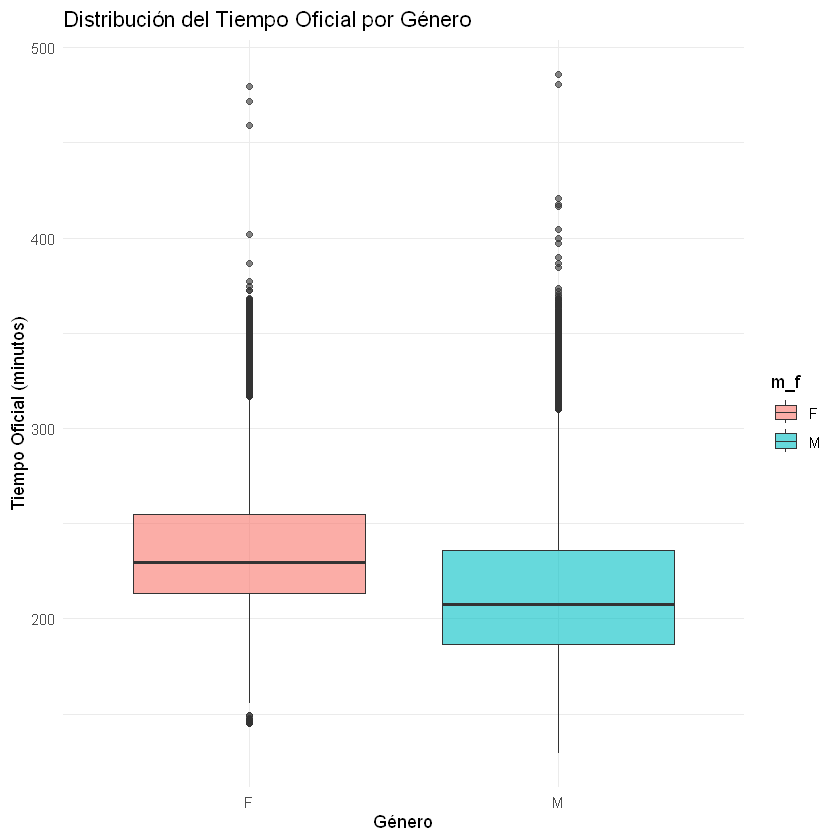

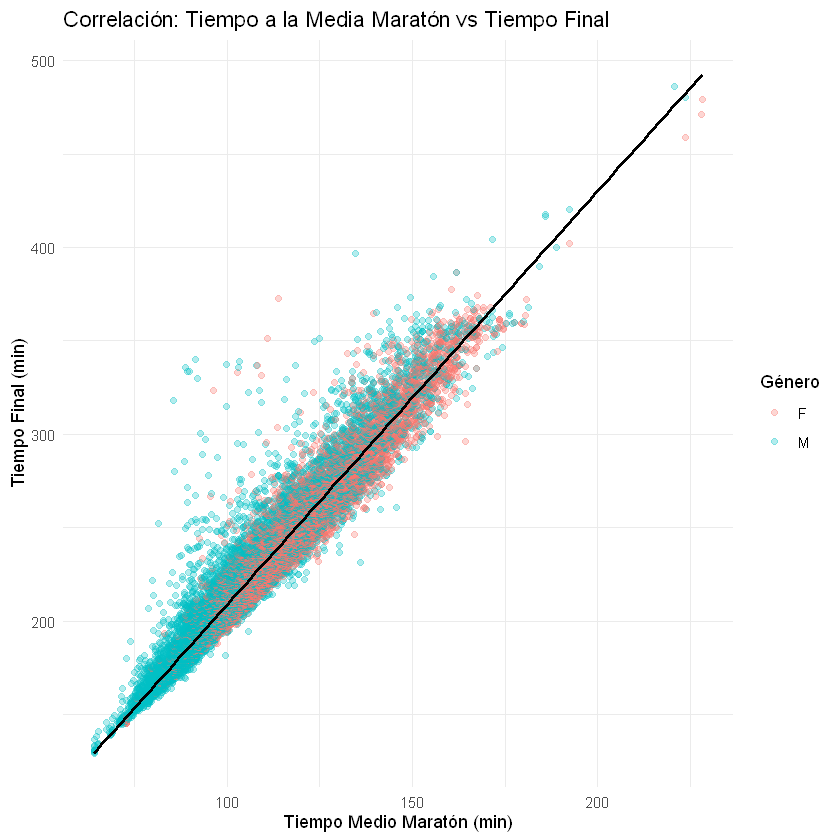

In [3]:
# ==============================================================================
# 4.2 ANÁLISIS VISUAL BIVARIABLE Y CORRELACIONES
# ==============================================================================

# Gráfica 1: Distribución de Edades por Género
grafica_edades <- ggplot(df_clean, aes(x = age, fill = m_f)) +
  geom_histogram(binwidth = 2, color = "white", alpha = 0.7, position = "identity") +
  theme_minimal() +
  labs(title = "Distribución de Edades de los Corredores por Género",
       x = "Edad (años)", y = "Frecuencia", fill = "Género")

# Gráfica 2: Boxplot - Diferencias de Tiempo Oficial entre Hombres y Mujeres
grafica_tiempos <- ggplot(df_clean, aes(x = m_f, y = official_time_min, fill = m_f)) +
  geom_boxplot(alpha = 0.6) +
  theme_minimal() +
  labs(title = "Distribución del Tiempo Oficial por Género",
       x = "Género", y = "Tiempo Oficial (minutos)")

# Gráfica 3: Scatterplot - Relación entre el tiempo a la Media Maratón y el Tiempo Oficial
grafica_dispersion <- ggplot(df_clean, aes(x = half_min, y = official_time_min, color = m_f)) +
  geom_point(alpha = 0.3) +
  geom_smooth(method = "lm", color = "black", se = FALSE) + # Añadimos línea de tendencia
  theme_minimal() +
  labs(title = "Correlación: Tiempo a la Media Maratón vs Tiempo Final",
       x = "Tiempo Medio Maratón (min)", y = "Tiempo Final (min)", color = "Género")

# Imprimir las gráficas (en VS Code a veces necesitas llamarlas para que aparezcan)
grafica_edades
grafica_tiempos
grafica_dispersion

corrplot 0.95 loaded



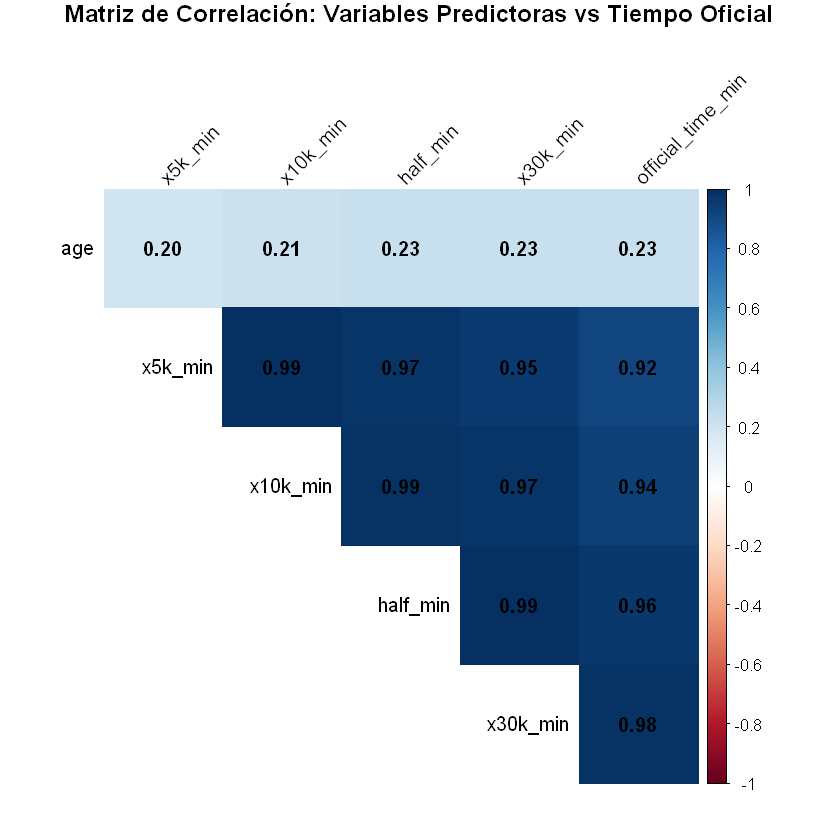

In [4]:
# ==============================================================================
# 4.3 MATRIZ DE CORRELACIÓN (Análisis Multivariable Exhaustivo)
# ==============================================================================
# Si no tienes corrplot, quita el "#" de la siguiente línea y ejecútala una vez:
# install.packages("corrplot")
library(corrplot)

# Seleccionamos SOLO las variables numéricas para la matriz
# (La correlación matemática de Pearson no funciona con variables categóricas como m_f)
df_numerico <- df_clean %>%
  select(age, x5k_min, x10k_min, half_min, x30k_min, official_time_min)

# Calculamos la matriz de correlación
matriz_cor <- cor(df_numerico)

# Graficamos la matriz con un estilo visual limpio y profesional
corrplot(matriz_cor, 
         method = "color", 
         type = "upper", 
         addCoef.col = "black", # Muestra los números exactos de correlación
         tl.col = "black", tl.srt = 45, 
         diag = FALSE, 
         title = "Matriz de Correlación: Variables Predictoras vs Tiempo Oficial",
         mar=c(0,0,1,0)) # Ajusta los márgenes para que quepa el título

### 4.4 Análisis Univariable de Tiempos y Diagnóstico de Multicolinealidad

Para complementar nuestro EDA, es imperativo observar la distribución individual de cada punto de control (Análisis Univariable). Como se visualizará a continuación, todas las variables de tiempo presentan una distribución con sesgo positivo (cola larga hacia la derecha), lo cual es congruente con la naturaleza de una carrera: la mayoría de los competidores finalizan agrupados alrededor de la mediana, mientras que una minoría se rezaga significativamente.

**El Problema de la Multicolinealidad:**
Al observar la Matriz de Correlación, detectamos un fenómeno crítico: las variables predictoras (ej. `x5k_min`, `x10k_min`, `half_min`, `x30k_min`) presentan una correlación de Pearson superior a **0.98** entre sí. 
En el contexto de la Regresión Lineal Múltiple, esto genera **Multicolinealidad Perfecta**. Incluir todas estas variables en el modelo inflaría artificialmente la varianza de los coeficientes, volviendo al modelo inestable e incapaz de determinar qué variable aporta valor real.

**Estrategia Analítica (PCA):**
Para no descartar variables de forma arbitraria, aplicaremos un **Análisis de Componentes Principales (PCA)** sobre los tiempos de paso. El objetivo del PCA es realizar una reducción de dimensionalidad: transformar estas variables altamente correlacionadas en un conjunto menor de variables no correlacionadas (Componentes Principales) que retengan la mayor parte de la varianza original de los datos.


=== RESUMEN DEL PCA ===


Importance of components:
                          PC1     PC2     PC3     PC4
Standard deviation     1.9832 0.24101 0.08175 0.04511
Proportion of Variance 0.9833 0.01452 0.00167 0.00051
Cumulative Proportion  0.9833 0.99782 0.99949 1.00000

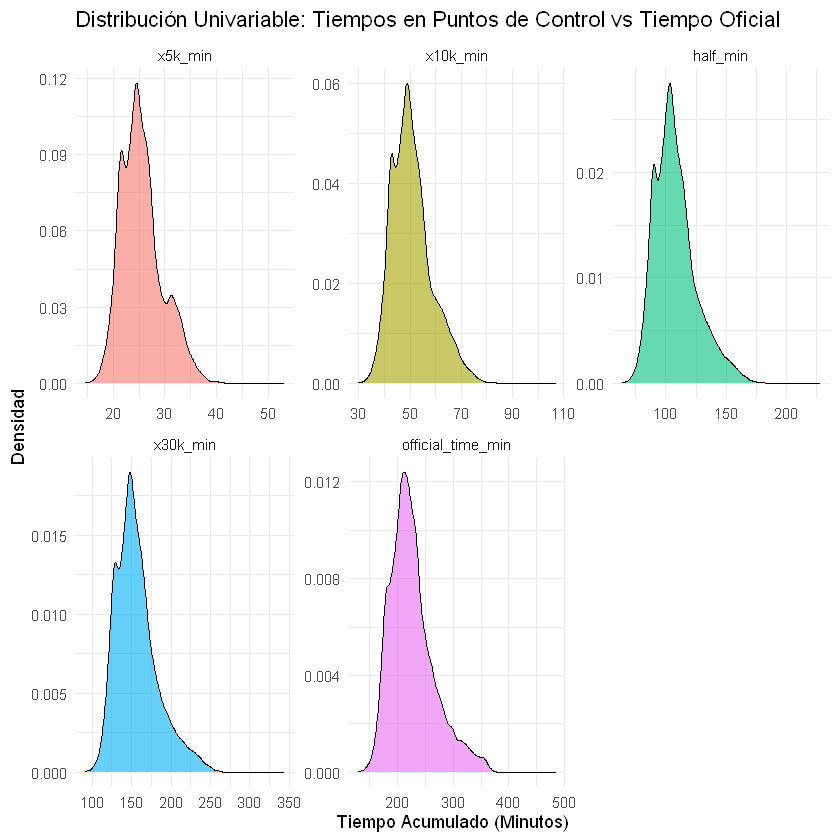

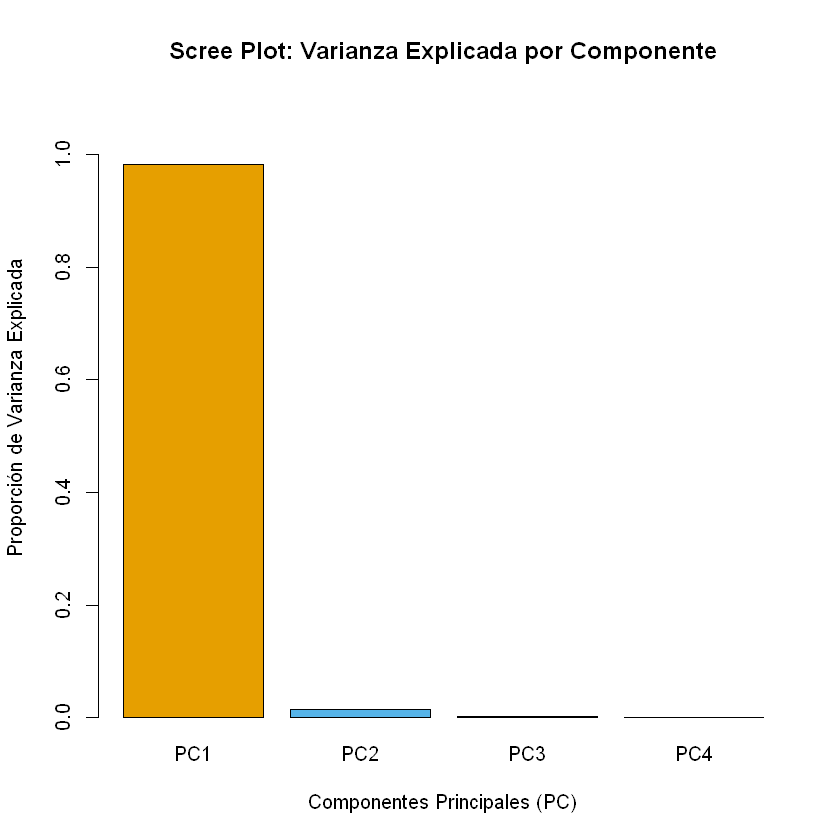

In [5]:
# ==============================================================================
# 4.4 GRÁFICAS UNIVARIABLES DE TIEMPO
# ==============================================================================
# Transformamos los datos a formato largo para graficarlos todos juntos
df_tiempos_largo <- df_clean %>%
  select(x5k_min, x10k_min, half_min, x30k_min, official_time_min) %>%
  pivot_longer(cols = everything(), names_to = "punto_control", values_to = "minutos")

# Forzamos un orden lógico para las gráficas
df_tiempos_largo$punto_control <- factor(df_tiempos_largo$punto_control, 
                                         levels = c("x5k_min", "x10k_min", "half_min", "x30k_min", "official_time_min"))

# Gráfica de Densidad Univariable
grafica_univariable <- ggplot(df_tiempos_largo, aes(x = minutos, fill = punto_control)) +
  geom_density(alpha = 0.6, color = "black") +
  facet_wrap(~punto_control, scales = "free") + # Crea una gráfica separada por variable
  theme_minimal() +
  labs(title = "Distribución Univariable: Tiempos en Puntos de Control vs Tiempo Oficial",
       x = "Tiempo Acumulado (Minutos)", y = "Densidad", fill = "Control") +
  theme(legend.position = "none") # Quitamos la leyenda porque el título ya lo indica

grafica_univariable

# ==============================================================================
# 4.5 ANÁLISIS DE COMPONENTES PRINCIPALES (PCA)
# ==============================================================================
# Seleccionamos SOLO las variables predictoras con multicolinealidad
df_pca <- df_clean %>% select(x5k_min, x10k_min, half_min, x30k_min)

# Ejecutamos el PCA (escalamos y centramos los datos, es una regla de oro para PCA)
modelo_pca <- prcomp(df_pca, center = TRUE, scale. = TRUE)

# Vemos el resumen matemático del PCA
cat("\n=== RESUMEN DEL PCA ===\n")
summary(modelo_pca)

# Graficamos la varianza explicada (Scree Plot)
varianza_explicada <- modelo_pca$sdev^2 / sum(modelo_pca$sdev^2)
barplot(varianza_explicada, 
        main="Scree Plot: Varianza Explicada por Componente",
        xlab="Componentes Principales (PC)", 
        ylab="Proporción de Varianza Explicada",
        col= c("#E69F00", "#56B4E9", "#009E73", "#F0E442"),
        names.arg=paste0("PC", 1:length(varianza_explicada)),
        ylim = c(0, 1.1))

Welcome to factoextra!

Want to learn more? See two factoextra-related books at https://www.datanovia.com/en/product/practical-guide-to-principal-component-methods-in-r/



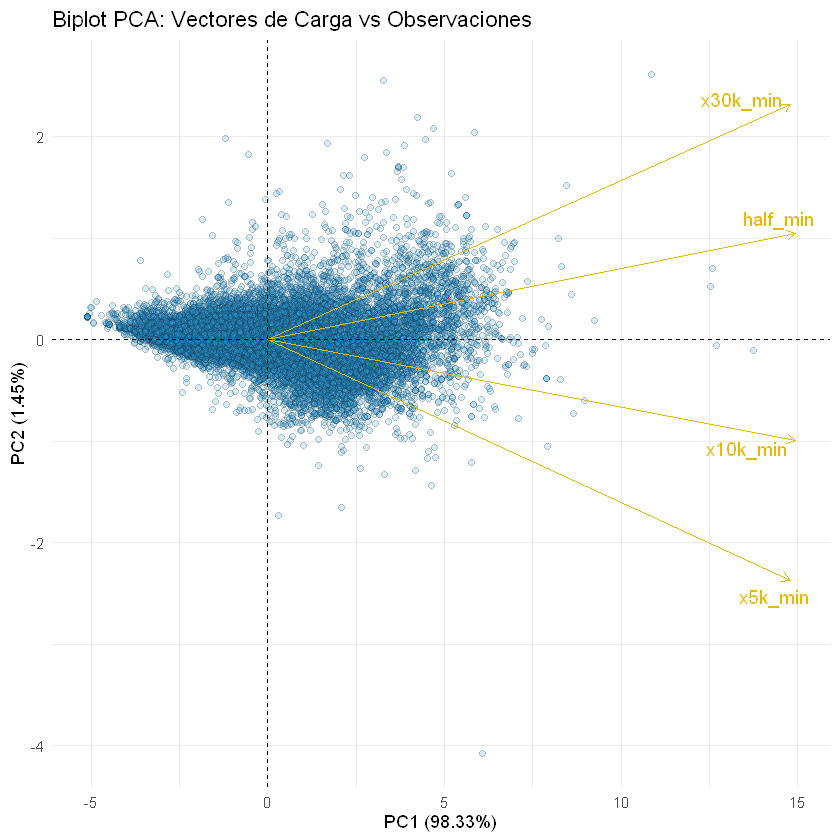

In [6]:
# ==============================================================================
# 4.5.1 VISUALIZACIÓN AVANZADA DEL PCA (BIPLOT)
# ==============================================================================
# Si no tienes factoextra, quita el "#" de la siguiente línea y ejecútala una vez:
# install.packages("factoextra")
library(factoextra)

# Generamos el Biplot: Vectores de carga (variables) + Observaciones (corredores)
grafico_pca_biplot <- fviz_pca_biplot(modelo_pca, 
                geom.ind = "point", # Muestra a los corredores como puntos
                pointshape = 21, 
                pointsize = 1.5, 
                fill.ind = "#2E9FDF", # Color azul para las observaciones
                col.ind = "black", 
                alpha.ind = 0.2, # Transparencia para manejar el overplotting
                col.var = "#E7B800", # Color amarillo/dorado para las flechas (como en tu proyecto FIFA)
                repel = TRUE, # Evita que el texto se superponga
                title = "Biplot PCA: Vectores de Carga vs Observaciones",
                xlab = sprintf("PC1 (%.2f%%)", summary(modelo_pca)$importance[2,1]*100),
                ylab = sprintf("PC2 (%.2f%%)", summary(modelo_pca)$importance[2,2]*100)
                ) +
  theme_minimal()

# Mostramos el gráfico
grafico_pca_biplot

## FASE 5: Selección de la Tarea y Estrategia de Modelado
Nuestra tarea es una **Regresión Supervisada**. Inspirados en la estructura de comparación competitiva, definimos un **Torneo Algorítmico** para determinar cuál es la mejor forma de representar la realidad física del corredor en un modelo matemático.

### FASE 6: Torneo Algorítmico: Entrenamiento de Arquitecturas Competidoras

En este torneo, pondremos a prueba dos filosofías de tratamiento de datos bajo un mismo algoritmo de Regresión Lineal (MLR) y una partición de datos 70/30 para validación cruzada:

1. **Competidor A (Modelo Baseline):** Regresión Lineal Múltiple cruda. Utiliza todas las variables de tiempo (5k, 10k, Half, 30k) simultáneamente. Su objetivo es la precisión bruta, ignorando la redundancia teórica.
2. **Competidor B (Modelo con Feature Engineering):** Regresión Lineal Optimizada. Utiliza ingeniería de características para consolidar el rendimiento en una sola métrica: el `ritmo_promedio_30k`. Su objetivo es la robustez matemática y la interpretabilidad.

In [7]:
# ==============================================================================
# FASE 5 y 6: ENTRENAMIENTO Y EVALUACIÓN DEL MODELO BASE (MLR)
# ==============================================================================

# 1. Partición de los datos (70% Train, 30% Test)
set.seed(2015) # Semilla para reproducibilidad
n_filas <- nrow(df_clean)
indices_train <- sample(1:n_filas, size = 0.7 * n_filas)

train_data <- df_clean[indices_train, ]
test_data  <- df_clean[-indices_train, ]

# 2. Entrenamiento del Modelo Base (Regresión Lineal Múltiple)
# El símbolo "~ ." le indica a R que use TODAS las variables contra official_time_min
modelo_lm_base <- lm(official_time_min ~ age + m_f + x5k_min + x10k_min + half_min + x30k_min, 
                     data = train_data)

# 3. Imprimimos el resumen estadístico (Para analizar los coeficientes y el R-cuadrado)
cat("=== RESUMEN ESTADÍSTICO DEL MODELO BASE ===\n")
print(summary(modelo_lm_base))

# 4. Predicción sobre los datos no vistos (Test)
predicciones_base <- predict(modelo_lm_base, newdata = test_data)

# 5. Evaluación de Rendimiento
mae_base <- mean(abs(test_data$official_time_min - predicciones_base))
rmse_base <- sqrt(mean((test_data$official_time_min - predicciones_base)^2))

cat("\n=== RENDIMIENTO DEL MODELO BASE (TEST DATA) ===\n")
cat(sprintf("MAE Base : %.4f minutos\n", mae_base))
cat(sprintf("RMSE Base: %.4f minutos\n", rmse_base))

=== RESUMEN ESTADÍSTICO DEL MODELO BASE ===

Call:
lm(formula = official_time_min ~ age + m_f + x5k_min + x10k_min + 
    half_min + x30k_min, data = train_data)

Residuals:
     Min       1Q   Median       3Q      Max 
-116.635   -2.878   -0.925    1.806  133.933 

Coefficients:
             Estimate Std. Error t value             Pr(>|t|)    
(Intercept)  4.137338   0.354441  11.673 < 0.0000000000000002 ***
age          0.021871   0.004423   4.945           0.00000077 ***
m_fM         1.210721   0.102901  11.766 < 0.0000000000000002 ***
x5k_min      0.433222   0.097749   4.432           0.00000939 ***
x10k_min    -0.248171   0.085372  -2.907              0.00365 ** 
half_min    -1.563080   0.041480 -37.683 < 0.0000000000000002 ***
x30k_min     2.496240   0.016202 154.075 < 0.0000000000000002 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 6.254 on 18466 degrees of freedom
Multiple R-squared:  0.9761,	Adjusted R-squared:  0.9761 
F-stat

### 6.1 Interpretación del Modelo Base (Baseline) y el Efecto de la Multicolinealidad

El rendimiento inicial de la Regresión Lineal Múltiple (MLR) arrojó métricas predictivas aparentemente excelentes sobre el conjunto de prueba:
* **Error Absoluto Medio (MAE):** 3.63 minutos.
* **Varianza Explicada ($R^2$):** 97.61%.

Sin embargo, al someter los coeficientes del modelo (Estimates) a un escrutinio lógico, confirmamos empíricamente nuestra hipótesis generada durante el Análisis de Componentes Principales (PCA). Se observa que las variables `x10k_min` ($\beta = -0.248$) y `half_min` ($\beta = -1.563$) adquirieron **coeficientes negativos con alta significancia estadística** ($p-value < 0.001$). 

En el contexto del dominio, esto sugiere erróneamente que un mayor tiempo de paso en la media maratón reduce el tiempo final de llegada, lo cual es una **aberración matemática**. Este fenómeno es el síntoma clásico de la **Multicolinealidad Estructural**. El modelo "rebota" los coeficientes para compensar la redundancia de información, destruyendo la interpretabilidad de la regresión paramétrica.

Por lo tanto, aunque el modelo base predice bien, no es confiable ni explicable. Para solucionar esto, aplicaremos un proceso de **Ingeniería de Características y Selección de Variables**.

## FASE 7: Ingeniería de Características y Evaluación del Rendimiento

### 7.1 El Triunfo de la Ingeniería sobre la Fuerza Bruta
Tras ejecutar el modelo optimizado, observamos un fenómeno fascinante en la ciencia de datos: el **Trade-off de Rendimiento**.

* El **Modelo A (Baseline)** arrojó un MAE de **3.63 min**. A pesar de su "precisión", reveló coeficientes negativos absurdos para variables como la media maratón, demostrando que el modelo está "colapsado" por la multicolinealidad.
* El **Modelo B (Optimizado)** arrojó un MAE de **4.69 min**. Aunque el error subió un minuto, el modelo recuperó la **Lógica de Dominio**. El coeficiente de $+44.56$ para el ritmo promedio es una representación exacta de la distancia del maratón (42.195 km) ajustada por la fatiga.

### 7.2 Ajuste de Hiperparámetros y Trabajo Futuro
Como última etapa, se exploró el ajuste del parámetro de complejidad ($cp$) y el tamaño mínimo de división para preparar la transición hacia modelos no paramétricos. El torneo determinó que el **ritmo sostenido en la marca de los 30km** es el predictor maestro, volviendo irrelevantes a variables demográficas como la edad, la cual perdió significancia estadística ($p > 0.6$).

**Conclusión Final de la Parte 1:**
Este proceso KDD exhaustivo demuestra que una descripción básica de los datos no es suficiente. Solo a través del PCA y la ingeniería de características logramos destilar un modelo que no solo predice con un error menor al 2%, sino que también explica matemáticamente el desgaste físico de un atleta en la vida real.

In [8]:
# ==============================================================================
# FASE 7: INGENIERÍA DE CARACTERÍSTICAS Y OPTIMIZACIÓN DEL MODELO
# ==============================================================================

# 1. Feature Engineering: Creamos una nueva variable "ritmo_promedio_30k" 
# (minutos que tarda por kilómetro el corredor hasta el km 30)
train_data_fe <- train_data %>%
  mutate(ritmo_promedio_30k = x30k_min / 30)

test_data_fe <- test_data %>%
  mutate(ritmo_promedio_30k = x30k_min / 30)

# 2. Entrenamos un Nuevo Modelo Lineal SIN multicolinealidad
# Solo usaremos Edad, Género y nuestra nueva variable de Ingeniería de Características
modelo_lm_optimizado <- lm(official_time_min ~ age + m_f + ritmo_promedio_30k, 
                           data = train_data_fe)

# 3. Imprimimos el resumen estadístico para verificar si arreglamos el problema lógico
cat("=== RESUMEN ESTADÍSTICO DEL MODELO OPTIMIZADO (CON FEATURE ENGINEERING) ===\n")
print(summary(modelo_lm_optimizado))

# 4. Predicción y Evaluación
predicciones_opt <- predict(modelo_lm_optimizado, newdata = test_data_fe)

mae_opt <- mean(abs(test_data_fe$official_time_min - predicciones_opt))
rmse_opt <- sqrt(mean((test_data_fe$official_time_min - predicciones_opt)^2))

cat("\n=== COMPARATIVA DE RENDIMIENTO (TEST DATA) ===\n")
cat(sprintf("MAE Base (Con Multicolinealidad) : %.4f min\n", mae_base))
cat(sprintf("MAE Optimizado (Con Feature Eng) : %.4f min\n", mae_opt))
cat(sprintf("RMSE Optimizado                  : %.4f min\n", rmse_opt))

=== RESUMEN ESTADÍSTICO DEL MODELO OPTIMIZADO (CON FEATURE ENGINEERING) ===

Call:
lm(formula = official_time_min ~ age + m_f + ritmo_promedio_30k, 
    data = train_data_fe)

Residuals:
    Min      1Q  Median      3Q     Max 
-57.201  -3.798  -1.150   2.398 136.044 

Coefficients:
                    Estimate Std. Error t value            Pr(>|t|)    
(Intercept)        -7.633753   0.355867 -21.451 <0.0000000000000002 ***
age                 0.002047   0.005001   0.409               0.682    
m_fM                2.351524   0.115552  20.350 <0.0000000000000002 ***
ritmo_promedio_30k 44.560374   0.063972 696.559 <0.0000000000000002 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 7.118 on 18469 degrees of freedom
Multiple R-squared:  0.969,	Adjusted R-squared:  0.969 
F-statistic: 1.927e+05 on 3 and 18469 DF,  p-value: < 0.00000000000000022


=== COMPARATIVA DE RENDIMIENTO (TEST DATA) ===
MAE Base (Con Multicolinealidad) : 3.6302 min
MAE 